# Resolutor SMT con PhaseAND/PhaseOR

Este *notebook* implementa una arquitectura cuántica escalable de múltiples registros para resolver problemas de teoría de satisfacibilidad módulo (SMT) utilizando el **algoritmo de Grover**. Este es un enfoque similar al propuesto por Lin et al. (2023). En lugar de agrupar la evaluación de todas las condiciones en un único registro que represente los valores de una variable en superposición, se distribuye la evaluación de $m$ cláusulas en $m$ registros independientes. Estos registros actúan como las unidades de información propuestas en el artículo. La codificación de los registros se ve representada por la inicialización de una variable en cada registro, o bien mediante la sincincronización de esta variable cuando es representada por varios registros. La evaluación de cada cláusula se realiza sobre el ancilla componiendo así la fórmula a satisfacer. De este modo, las operaciones **`PhaseAND`** y/o **`PhaseOR`** marcan con fase $π$ los estados que satisfacen la relación lógica completa siguiendo la conjunción (**`AND`**) o la disyunción (**`OR`**).

> Lin, S. W., Wang, T. F., Chen, Y. R., Hou, Z., Sanán, D., & Teo, Y. S. (2023). A parallel and distributed quantum SAT solver based on entanglement and quantum teleportation. arXiv preprint arXiv:2308.03344. [https://doi.org/10.48550/arXiv.2308.03344](https://doi.org/10.48550/arXiv.2308.03344)



En definitiva, hemos creado un resolutor *SMT* aplicando las abstracciones lógicas de mayor nivel (**`PhaseAND`**, **`PhaseOR`** y sus negaciones) presentadas en el artículo. Para su implementación se utiliza Qiskit (v2.3.1), especificado en el documento **`requirements.txt`**. Este es un *framework* que normalmente exige programar a muy bajo nivel (puerta a puerta), pero en este caso hemos especificado los componentes del resolutor en módulos aislados para permitir construir en este notebook el resolutor sin necesidad de instanciar puertas individuales. Este diseño demuestra el potencial y el tipo de operaciones complejas que se pueden crear de forma modular estructurando el código con estas abstracciones. Aún así, toda la creación de estas estructuras requieren crearlas de forma incremental desde este menor nivel, por lo que este lenguaje no parece ser del todo apropiado para mayores escalas.

## Importación de Librerías
Importamos las clases fundamentales de Qiskit para la construcción, transpilación y simulación del circuito cuántico, junto con las herramientas gráficas (`matplotlib`, `seaborn`).

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from src import (
    oracle_less, oracle_eq, oracle_greatereq, oracle_interval,
    PhaseAND, PhaseNAND, PhaseOR, PhaseNOR,
    diffuser, ghz_init
)


## 6. Iteración de Grover

Esta función engloba todas las piezas anteriores para construir una iteración completa del Algoritmo de Grover resolviendo nuestra fórmula modularmente:

1. **Computación de Oráculos**: Anexamos los oráculos matemáticos para que evalúen las restricciones independientes en cada registro.
2. **Evaluación Lógica**: Aplicamos nuestra abstracción `PhaseNOR` para inyectar la fase negativa a la combinación booleana objetivo. Se utiliza frente a `PhaseOR` simplemente porque requiere menor profundida y actúan de forma equivalente en este caso.
3. **Descomputación**: Aplicamos nuevamente los oráculos. Al ser operadores hermíticos ($U = U^\dagger$), los ancillas retornan de forma determinista a su estado base ($|0\rangle$), limpiando los ancillas.
4. **Difusión**: Por último, ejecutamos el `diffuser` para amplificar la probabilidad del subespacio correcto.

Cada registro cuántico se encarga de codificar la información de una condición específica evaluada por un oráculo, siguiendo una codificación basada en aritmética modular. En este caso práctico, el algoritmo está diseñado para encontrar el estado $x$ que satisfaga la siguiente fórmula en forma normal disyuntiva (DNF):

$$F = [(x > 12) \land (x < 17)] \lor (x = 38) \lor [(x > 39) \land (x < 43)] \lor (x \ge 56) \pmod{64}$$

In [ ]:
def grover_iteration(main_circuit: QuantumCircuit, q_regs: list, qubits: int):
  """
  Applies a single iteration of Grover's algorithm to the quantum circuit.
  This involves applying probability oracles, a boolean combination, and the
  diffuser.

  This case solves the formula in CNF:
  F = [(x > 12) ∧ (x < 17)] ∨ (x = 38) ∨ [(x > 39) ∧ (x < 43)] ∨ (x > 55)
                                                                 (mod 64)

  Args:
      main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                     the Grover iteration is applied.
      q_regs (list): A list of QuantumRegister objects representing the
                     clauses.
      qubits (int): The total number of qubits in each register, including the
                    ancilla qubit.

  Returns:
      QuantumCircuit: The modified Qiskit QuantumCircuit object after one Grover
                      iteration.
  """
  # List of oracles implemented as constraints
  # Beware that this implementation is manual, so the number of oracles and
  # registers must add up
  oracle_1 = oracle_interval(13, 17, qubits-1)
  oracle_2 = oracle_eq(38, qubits-1)
  oracle_3 = oracle_interval(40, 43, qubits-1)
  oracle_4 = oracle_greatereq(56, qubits-1)

  # Composing of the oracles into the circuit
  main_circuit.append(oracle_1, q_regs[0])
  main_circuit.append(oracle_2, q_regs[1])
  main_circuit.append(oracle_3, q_regs[2])
  main_circuit.append(oracle_4, q_regs[3])

  # Boolean combination of clauses
  # When using Grover, these abstractions are equivalent to their negations
  # as the algorithm performs up to global phase. The programmer needs to
  # consider that the amplification will be done on the minority subspace.
  # That is, if the PhaseNOR gate is applied but it marks most states, then the
  # ones that satisfy the OR relation will be amplified instead.
  PhaseNOR(main_circuit, q_regs, qubits)

  # Composing of the oracles adjoints into the circuit
  main_circuit.append(oracle_1, q_regs[0])
  main_circuit.append(oracle_2, q_regs[1])
  main_circuit.append(oracle_3, q_regs[2])
  main_circuit.append(oracle_4, q_regs[3])

  # Composing of the diffuser into the circuit
  # Created for only one variable instance, necessary modification otherwise
  diffuser(main_circuit, q_regs, qubits-1)

  return main_circuit

## 8. Configuración y Ejecución del Circuito

Una vez están implementadas todas las partes del circuito, se prueba sobre un caso concreto:

* Configuraremos **7 qubits por registro** (6 para codificar los datos y 1 como ancilla temporal), lo que nos permite abarcar un espacio de búsqueda del $0$ al $63$ ($2^6→\mod(64)$).
* Utilizaremos **$m = 4$ registros**, uno para cada una de las 4 cláusulas de nuestra fórmula DNF principal.

A continuación, instanciamos los registros, inicializamos siguiendo el entrelazamiento de los estados como combinaciones de GHZ, ejecutamos una iteración de Grover completa y visualizamos el diagrama. Gracias a nuestras abstracciones de alto nivel, un circuito enormemente complejo se convierte en una serie de bloques más limpios, manejables y expresivos.

Quantum registers, classical register, and quantum circuit initialized.


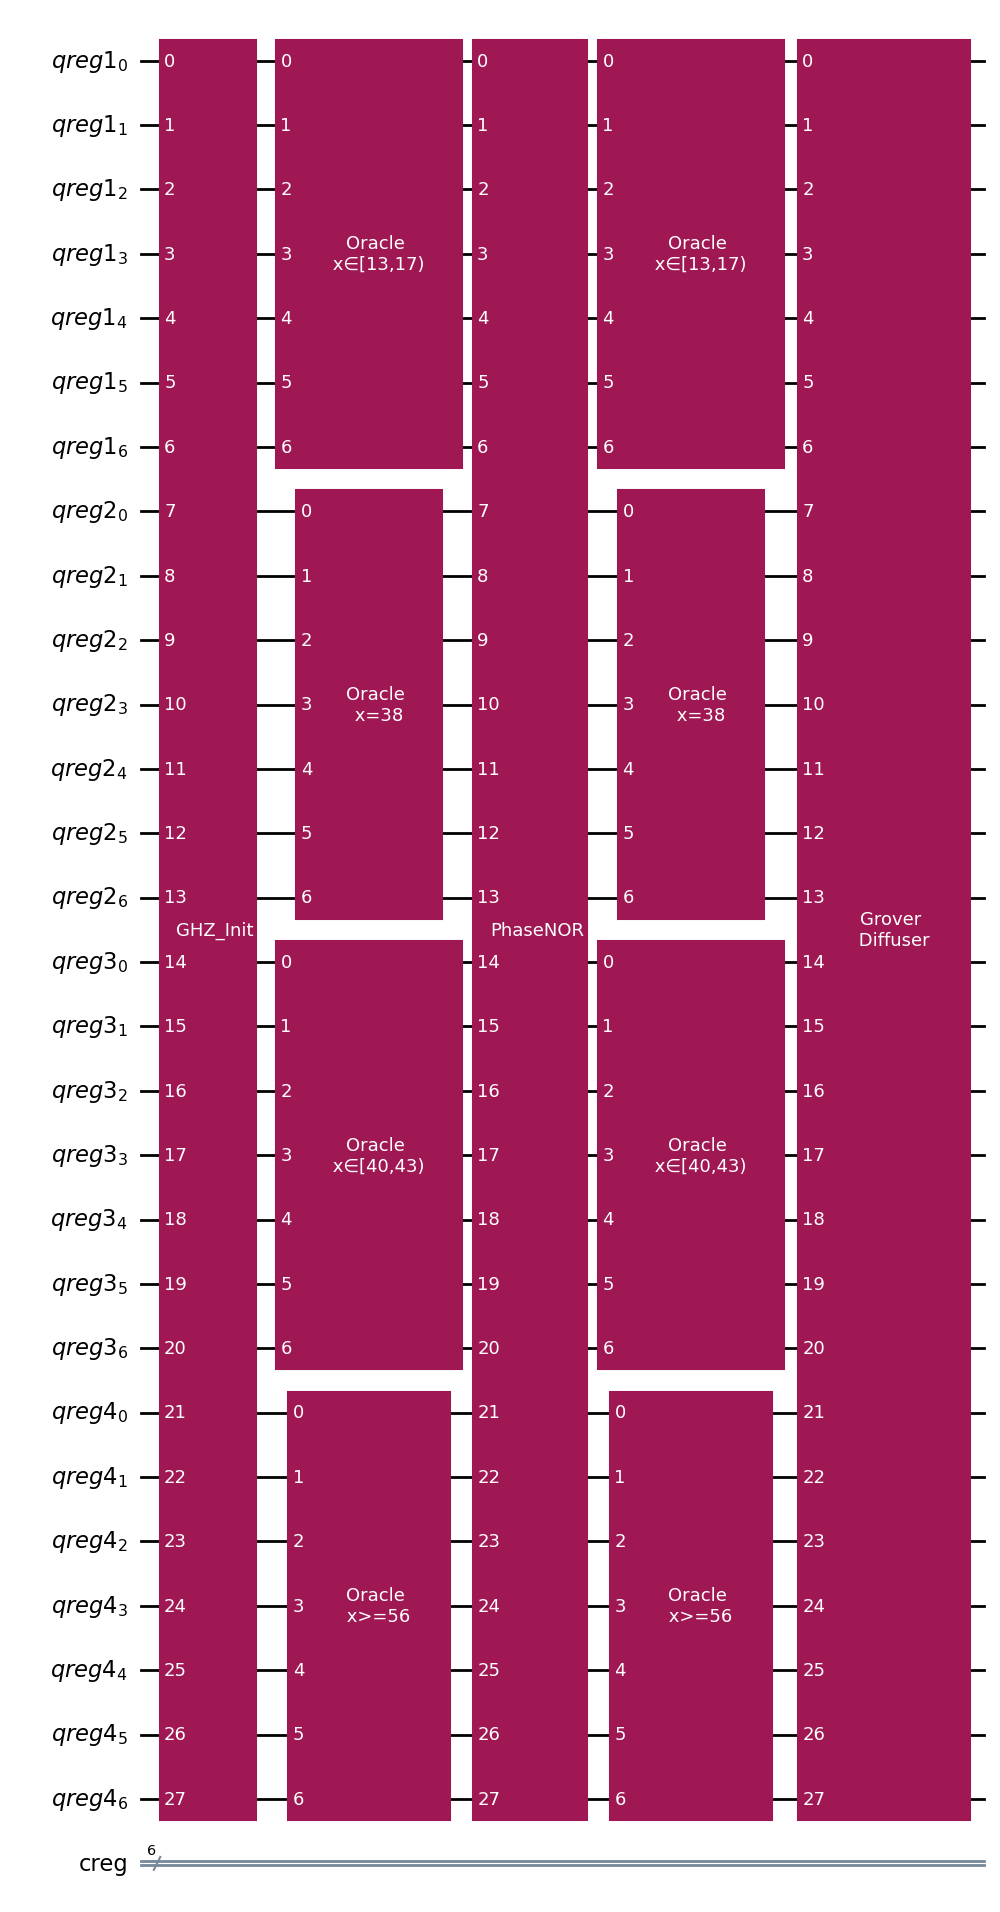

In [4]:
qubits = 7 # Number of qubits in each register, including the ancilla
m = 4 # Number of clauses (number of registers)

q_regs = [QuantumRegister(qubits, f'qreg{j+1}') for j in range(m)]
cr = ClassicalRegister(qubits-1, 'creg')
main_circuit = QuantumCircuit(*q_regs, cr)
print('Quantum registers, classical register, and quantum circuit initialized.')

ghz_init(main_circuit, q_regs, qubits)
grover_iteration(main_circuit, q_regs, qubits)
main_circuit.draw('mpl', fold=-1)

## 9. Medición, Simulación y Análisis de Resultados

In [5]:
def measurement(main_circuit: QuantumCircuit, q_regs: list,
                cr: ClassicalRegister, qubits: int, shots: int):
    """
    Performs the measurement on the primary quantum register, simulates the
    circuit, and plots the measurement outcomes. The keys in the output
    dictionary are inverted to convert from Qiskit's Little-Endian to standard
    Big-Endian notation.

    Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to be
                                       measured.
        q_regs (list): A list of QuantumRegister objects.
        cr (ClassicalRegister): The ClassicalRegister to store the outcomes.
        qubits (int): The total number of qubits in each register, without the
                      ancilla qubit.
        shots (int): The number of times the circuit is to be run.

    Returns:
        None. Prints the outcomes and displays a bar plot.
    """
    # Measure only first regsiter qubits
    for i in range(qubits):
        main_circuit.measure(q_regs[0][i], cr[i])

    # Initialize the simulator and transpile the circuit
    simulator = AerSimulator()
    compiled_circuit = transpile(main_circuit, simulator)

    # Execute the simulation
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    # Invert keys for standard notation (MSB at index 0)
    inverted_counts = {key[::-1]: value for key, value in counts.items()}

    # Sort by decimal value of the bitstring
    sorted_items = sorted(inverted_counts.items(), key=lambda kv: int(kv[0], 2))
    # Format: 010₂ = 2, in ascending decimal order
    formatted_counts = {f'{k}₂ = {int(k, 2)}': v for k, v in sorted_items}
    print(formatted_counts)

    print('Simulation completed. Measurement outcomes with inverted keys to ' +
          'maintain notation:')

    # Histogram for outcome results
    outcome_labels = list(formatted_counts.keys())
    outcome_values = list(formatted_counts.values())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=outcome_labels, y=outcome_values)
    plt.xlabel('Measurement Outcome')
    plt.ylabel('Counts')
    plt.title(f'Quantum Circuit Measurement Outcomes (shots = {shots})')
    plt.xticks(rotation=45, ha='center')
    plt.tight_layout()
    plt.show()

    return None

c:\Users\Usuario\Documents\GitHub\programando-abstraccion-cuantica\.venv\Lib\site-packages\samplomatic\__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


{'001101₂ = 13': 71, '001110₂ = 14': 71, '001111₂ = 15': 60, '010000₂ = 16': 69, '100110₂ = 38': 74, '101000₂ = 40': 55, '101001₂ = 41': 63, '101010₂ = 42': 60, '111000₂ = 56': 68, '111001₂ = 57': 58, '111010₂ = 58': 66, '111011₂ = 59': 53, '111100₂ = 60': 65, '111101₂ = 61': 43, '111110₂ = 62': 84, '111111₂ = 63': 64}
Simulation completed. Measurement outcomes with inverted keys to maintain notation:


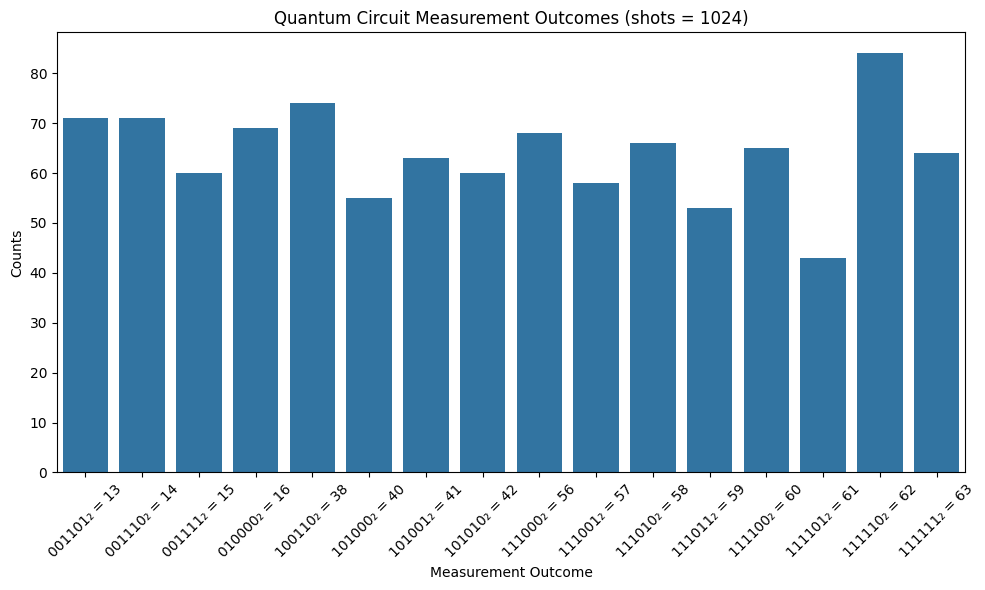

In [6]:
shots=1024
measurement(main_circuit, q_regs, cr, qubits-1, shots)

Como se observa en el histograma, las amplitudes de probabilidad han sido exitosamente amplificadas para los estados $\{13, 14, 15, 16, 38, 40, 41, 42, 56, 57, 58, 59, 60, 61, 62, 63\}$, demostrando que nuestro circuito cuántico modular ha resuelto satisfactoriamente la fórmula planteada.